In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt



sm_path = "../data/smartmeter_per_meter_ALL_D1364_sp1.parquet"

In [13]:
df_sm = pd.read_parquet(sm_path)

# Make sure timestamp is datetime and sorted
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_sm = df_sm.sort_values(["substation_id", "ts"])
df_sm.head()


,substation_id,transformer,meteringpointid,tegund,husveita_fastanumer,kennitalamaelistadar,ts,I_a,I_b,I_c,...,V_b,V_c,P_a,P_b,P_c,I_total,P_total,per_completed,n_completed,n_total_mps
0,1364,sp1,198855,Einstaklingur,198855,10725366,2025-11-01 12:00:00,9.750,NaN,NaN,...,NaN,NaN,2234.0045,NaN,NaN,9.750,2234.0045,0.994859,387,389
193,1364,sp1,198856,Einstaklingur,198856,10725367,2025-11-01 12:00:00,0.465,NaN,NaN,...,NaN,NaN,107.2395,NaN,NaN,0.465,107.2395,0.994859,387,389
386,1364,sp1,198857,Einstaklingur,198857,10725368,2025-11-01 12:00:00,0.720,NaN,NaN,...,NaN,NaN,166.0980,NaN,NaN,0.720,166.0980,0.994859,387,389
579,1364,sp1,198858,Einstaklingur,198858,10725369,2025-11-01 12:00:00,5.975,NaN,NaN,...,NaN,NaN,1369.7690,NaN,NaN,5.975,1369.7690,0.994859,387,389
772,1364,sp1,198859,Einstaklingur,198859,10725370,2025-11-01 12:00:00,1.875,NaN,NaN,...,NaN,NaN,432.4975,NaN,NaN,1.875,432.4975,0.994859,387,389


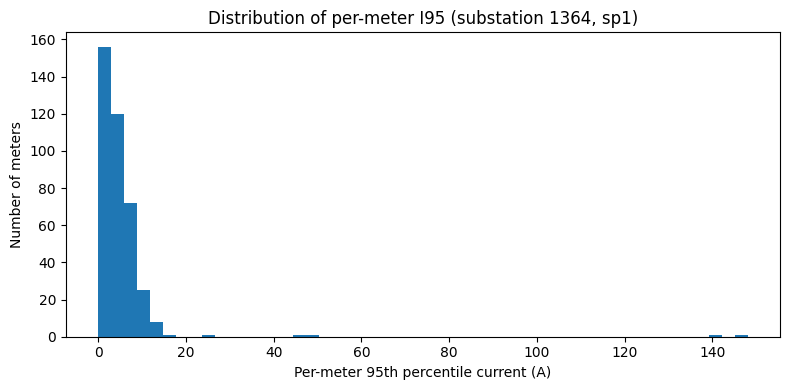

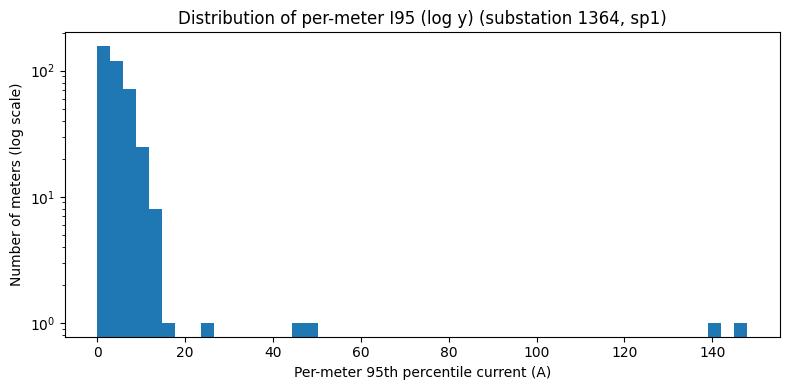

In [15]:
# --- Choose a current column to represent per-meter load ---
# I_total is safest because phases can be NaN for 1-phase meters.
col = "I_total"

# --- Capacity proxy: per-meter 95th percentile over the whole window ---
df=df_sm.copy()

s = (
    df_sm.groupby("meteringpointid")[col]
      .quantile(0.95)
      .rename("I95")
      .reset_index()
)


# --- Plot histogram of the capacity proxy ---
plt.figure(figsize=(8,4))
plt.hist(s["I95"], bins=50)
plt.xlabel("Per-meter 95th percentile current (A)")
plt.ylabel("Number of meters")
plt.title(f"Distribution of per-meter I95 (substation 1364, sp1)")
plt.tight_layout()
plt.show()

# Optional: log-scale y if there are a few very large meters
plt.figure(figsize=(8,4))
plt.hist(s["I95"], bins=50, log=True)
plt.xlabel("Per-meter 95th percentile current (A)")
plt.ylabel("Number of meters (log scale)")
plt.title(f"Distribution of per-meter I95 (log y) (substation 1364, sp1)")
plt.tight_layout()
plt.show()

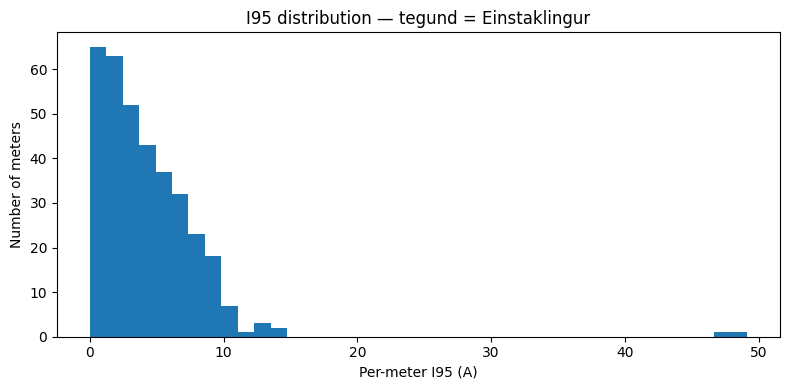

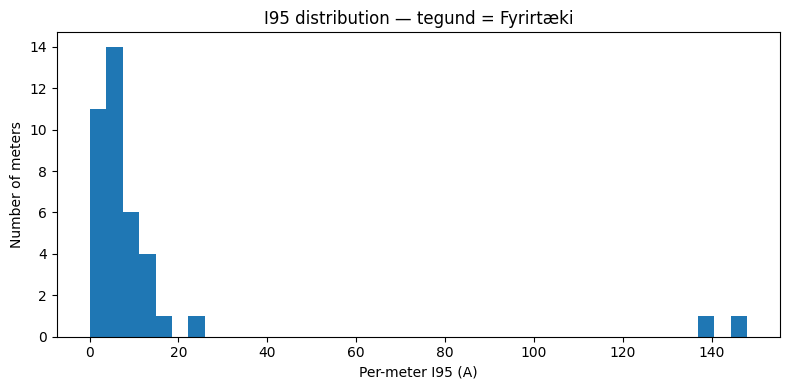

In [16]:
df["date"] = df["ts"].dt.date

daily_i95 = (
    df.groupby(["meteringpointid", "date"])[col]
      .quantile(0.95)
      .rename("I95_day")
      .reset_index()
)

s2 = (
    daily_i95.groupby("meteringpointid")["I95_day"]
             .median()
             .rename("I95_median_over_days")
             .reset_index()
)



# attach tegund per meter (take first non-null)
meta = (df.groupby("meteringpointid")["tegund"]
          .agg(lambda x: x.dropna().iloc[0] if x.dropna().size else np.nan)
          .reset_index())

s_plot = s.merge(meta, on="meteringpointid", how="left")

for t, g in s_plot.groupby("tegund"):
    plt.figure(figsize=(8,4))
    plt.hist(g["I95"], bins=40)
    plt.xlabel("Per-meter I95 (A)")
    plt.ylabel("Number of meters")
    plt.title(f"I95 distribution — tegund = {t}")
    plt.tight_layout()
    plt.show()


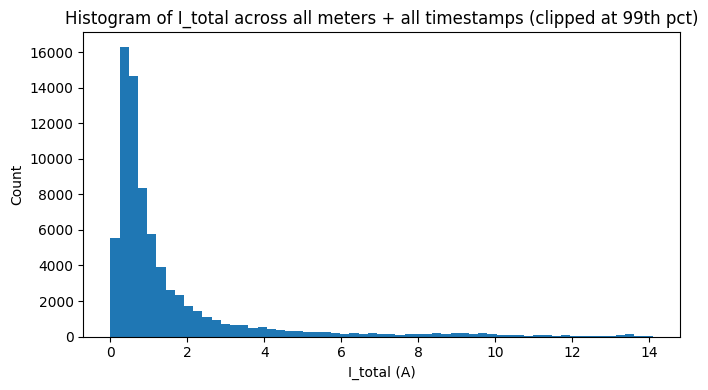

In [21]:
import numpy as np
import matplotlib.pyplot as plt

col = "I_total"

df = df_sm.copy()

# clean
vals = df[col].dropna().to_numpy()
vals = vals[vals >= 0]

# pick bins (simple + robust)
x_max = np.quantile(vals, 0.99)          # clip extreme tail for readability
bins = np.linspace(0, x_max, 60)

plt.figure(figsize=(7,4))
plt.hist(vals[vals <= x_max], bins=bins)
plt.xlabel(f"{col} (A)")
plt.ylabel("Count")
plt.title(f"Histogram of {col} across all meters + all timestamps (clipped at 99th pct)")
plt.tight_layout()
plt.show()

In [ ]:
substation_stats = (
    df_sm
    .groupby("substation_id")
    .agg(
        mean_I_a=("I_a", "mean"),
        mean_I_b=("I_b", "mean"),
        mean_I_c=("I_c", "mean"),
        mean_I_total=("I_total", "mean"),
        max_I_total=("I_total", "max"),
        mean_per_completed=("per_completed", "mean"),
        n_samples=("ts", "count"),
    )
    .reset_index()
)

substation_stats.head()


,substation_id,mean_I_a,mean_I_b,mean_I_c,mean_I_total,max_I_total,mean_per_completed,n_samples
0,1364,1.579044,4.120568,3.848033,2.03204,163.0,0.994859,74691


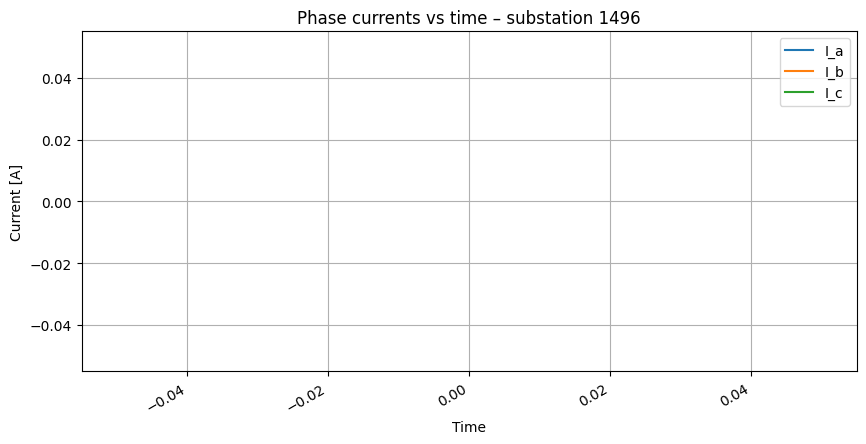

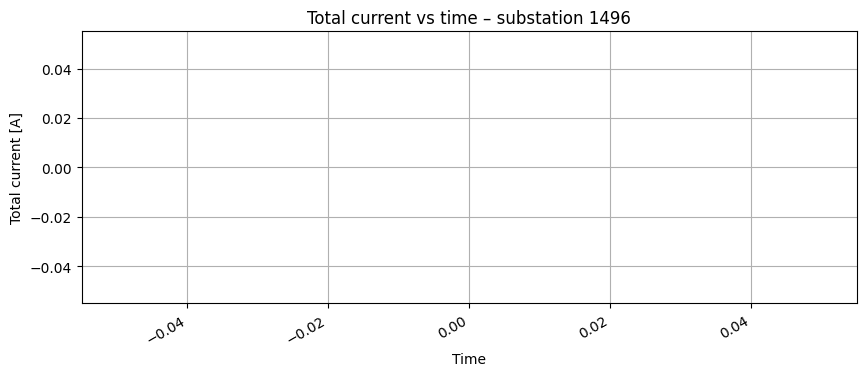

KeyError: 'n_mps'

In [ ]:
sub_id = 1496  # <-- change this
trafo_id = "sp1"

df_one = df_sm[(df_sm["substation_id"] == sub_id) & (df_sm["transformer"] == trafo_id)].copy()
df_one = df_one.sort_values("ts").set_index("ts")

# ---- Phase currents ----
df_one[["I_a", "I_b", "I_c"]].plot(figsize=(10, 5))
plt.title(f"Phase currents vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Current [A]")
plt.grid(True)
plt.show()

# ---- Total current ----
df_one["I_total"].plot(figsize=(10, 4))
plt.title(f"Total current vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Total current [A]")
plt.grid(True)
plt.show()

# ---- n_mps ----
df_one["n_mps"].plot(figsize=(10, 3))
plt.title(f"Number of active smart meters (n_mps) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("n_mps")
plt.grid(True)
plt.show()

# ---- per_completed ----
df_one["per_completed"].plot(figsize=(10, 3))
plt.title(f"Smart meter completeness (per_completed) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("per_completed (0–1)")
plt.grid(True)
plt.show()

print("avg total current:", df_one["I_total"].mean())


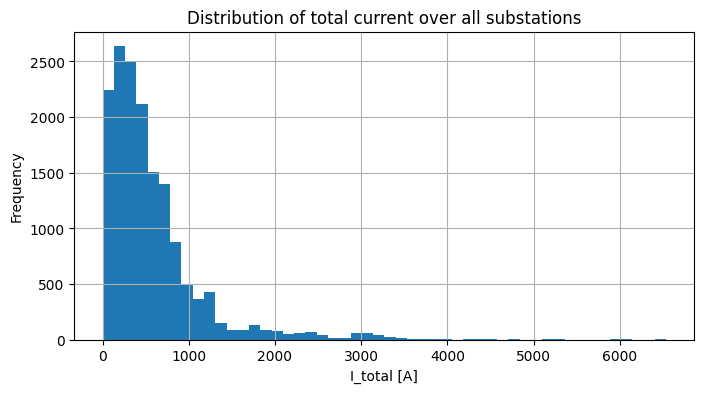

In [ ]:
df_sm["I_total"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of total current over all substations")
plt.xlabel("I_total [A]")
plt.grid(True)
plt.show()


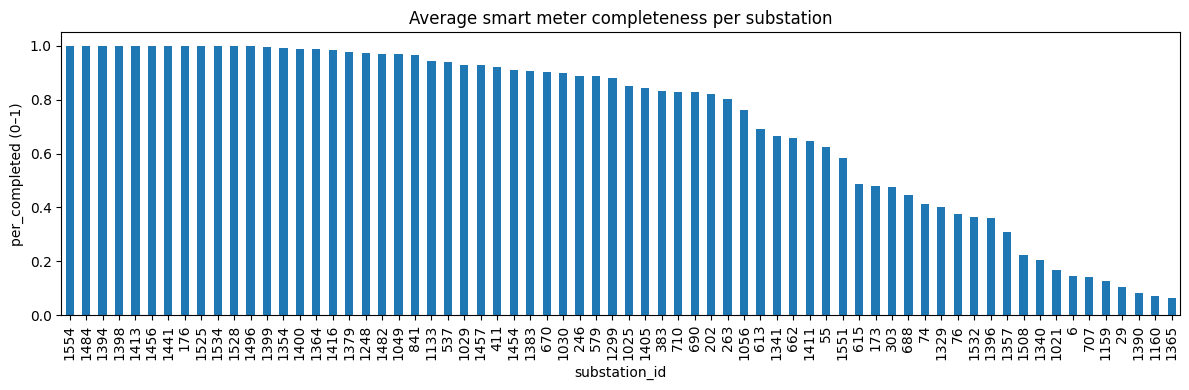

In [ ]:
avg_comp = (
    df_sm.groupby("substation_id")["per_completed"]
    .mean()
    .sort_values(ascending=False)
)

avg_comp.plot(kind="bar", figsize=(12, 4))
plt.title("Average smart meter completeness per substation")
plt.ylabel("per_completed (0–1)")
plt.xlabel("substation_id")
plt.tight_layout()
plt.show()


Cutoff = 0.90: keeping 31 of 68 substations


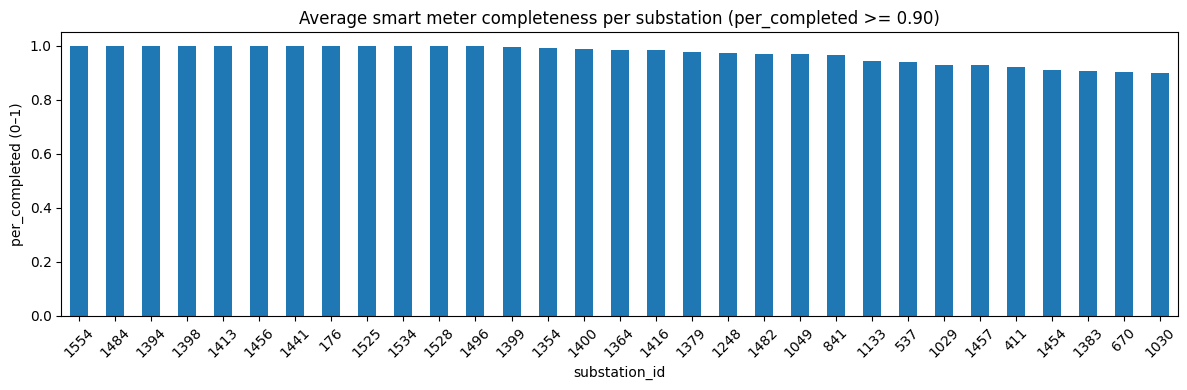

In [ ]:
# Set cutoff threshold (0.0 - 1.0). Substations with avg per_completed < cutoff will be excluded.
cutoff = 0.9

filtered = avg_comp[avg_comp >= cutoff]

print(f"Cutoff = {cutoff:.2f}: keeping {len(filtered)} of {len(avg_comp)} substations")
if filtered.empty:
    print("No substations meet the cutoff. Lower the threshold.")
else:
    ax = filtered.plot(kind="bar", figsize=(12, 4))
    ax.set_title(f"Average smart meter completeness per substation (per_completed >= {cutoff:.2f})")
    ax.set_ylabel("per_completed (0–1)")
    ax.set_xlabel("substation_id")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()